In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return -2 * y

def exact_solution(x):
    return np.exp(-2 * x)

def solve_euler(h, x_start, x_end, y0):
    num_steps = int((x_end - x_start) / h)
    x_vals = np.linspace(x_start, x_end, num_steps + 1)
    y_vals = np.zeros(num_steps + 1)
    y_vals[0] = y0
    
    for i in range(num_steps):
        y_vals[i + 1] = y_vals[i] + h * f(x_vals[i], y_vals[i])
    
    return x_vals, y_vals

# Parameters
h_values = [0.1, 0.5, 1.0, 1.5]
x_start, x_end = 0, 10
y0 = 1

h = 0.1 | Local Error: 0.0187 | Global Error: 1.8575e-09
h = 0.5 | Local Error: 0.3679 | Global Error: 2.0612e-09
h = 1.0 | Local Error: 1.1353 | Global Error: 1.0000e+00
h = 1.5 | Local Error: 2.0498 | Global Error: 6.4000e+01


<ipython-input-2-50c5c0d0976a>:26: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  plt.subplot(2, 1, 1)
<ipython-input-2-50c5c0d0976a>:30: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  plt.subplot(2, 1, 2)
<ipython-input-2-50c5c0d0976a>:34: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and r

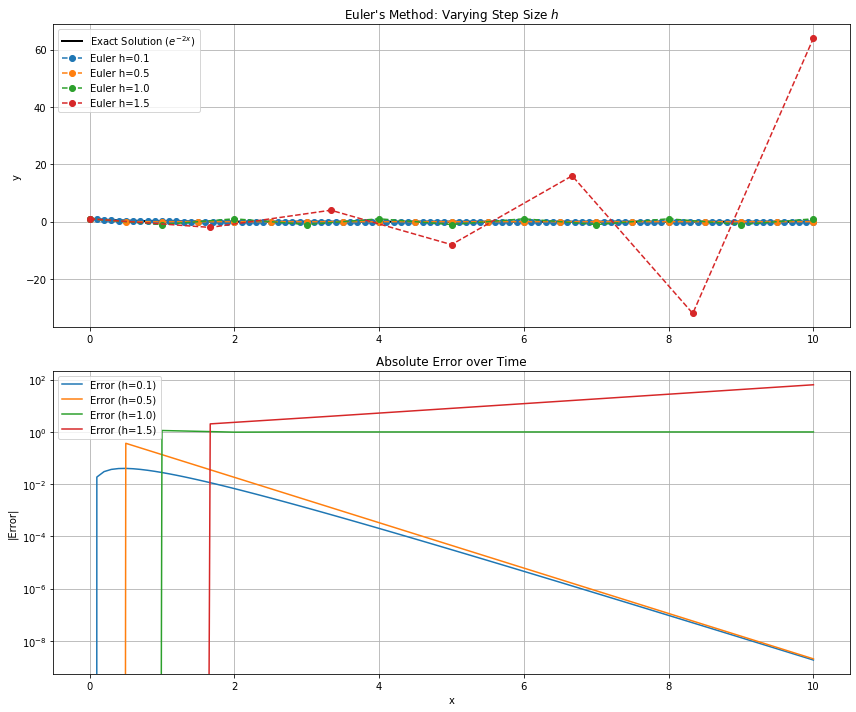

In [2]:
plt.figure(figsize=(12, 10))

# Subplot 1: Solutions
plt.subplot(2, 1, 1)
x_fine = np.linspace(x_start, x_end, 500)
plt.plot(x_fine, exact_solution(x_fine), 'k', lw=2, label="Exact Solution ($e^{-2x}$)")

# Subplot 2: Errors
plt.subplot(2, 1, 2)

for h in h_values:
    x_vals, y_vals = solve_euler(h, x_start, x_end, y0)
    y_exact = exact_solution(x_vals)
    
    # Calculate Local Error (error at the first step)
    y_1_euler = y0 + h * f(0, y0)
    y_1_exact = exact_solution(h)
    local_error = np.abs(y_1_euler - y_1_exact)
    
    # Calculate Global Error (error at the final x_end)
    global_error = np.abs(y_vals[-1] - exact_solution(x_end))
    
    print(f"h = {h:.1f} | Local Error: {local_error:.4f} | Global Error: {global_error:.4e}")
    
    # Plot solutions on top graph
    plt.subplot(2, 1, 1)
    plt.plot(x_vals, y_vals, 'o--', label=f"Euler h={h}")
    
    # Plot pointwise error on bottom graph
    plt.subplot(2, 1, 2)
    plt.plot(x_vals, np.abs(y_vals - y_exact), label=f"Error (h={h})")

# Formatting
plt.subplot(2, 1, 1)
plt.title("Euler's Method: Varying Step Size $h$")
plt.ylabel("y")
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.title("Absolute Error over Time")
plt.xlabel("x")
plt.ylabel("|Error|")
plt.yscale('log') # Log scale helps see small errors
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()